topics in machine learning 


Types and Algorithms of Machine Learning      :Supervised Learning ,Semi-Supervised Learning, Unsupervised Learning and Reinforcement Learning

neural networks or artificial neural networks :back propogration

deep learning

esemble learning

overfitting and underfitting 

regularization

cross validation

Performance metrics for classification problems :Confusion matrix , Recall or sensitivity (misses), ROC curve, AUC curve

artificial intelligence

data mining

pca




In [43]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn import linear_model
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [29]:
housing = pd.read_csv(r"/Users/apple/Documents/programming/datas/housing_prices.csv") # how to read a file

In [30]:
housing.describe()
housing.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [31]:
y = housing.SalePrice
housing_features = ['YearBuilt','OverallCond','FullBath','LotArea']
x = housing[housing_features]
z = housing.OverallCond


In [32]:
x.describe()

,YearBuilt,OverallCond,FullBath,LotArea
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1971.267808,5.575342,1.565068,10516.828082
std,30.202904,1.112799,0.550916,9981.264932
min,1872.000000,1.000000,0.000000,1300.000000
25%,1954.000000,5.000000,1.000000,7553.500000
50%,1973.000000,5.000000,2.000000,9478.500000
75%,2000.000000,6.000000,2.000000,11601.500000
max,2010.000000,9.000000,3.000000,215245.000000


In [33]:
x.head()


,YearBuilt,OverallCond,FullBath,LotArea
0,2003,5,2,8450
1,1976,8,2,9600
2,2001,5,2,11250
3,1915,5,1,9550
4,2000,5,2,14260


machine learning

supervised learning : Supervised learning involves learning a function that maps an input to an output based on example input-output pairs 

                     regression      : In regression models, the output is continuous
                     
                                      linear regression   : The idea of linear regression is simply finding a line that best fits the data. Extensions of linear regression include multiple linear regression

                                      decision tree       : Decision trees are a popular model, used in operations research, strategic planning, and machine learning. Each square above is called a node, and the more nodes you have, the more accurate your decision tree will be(generally). The last nodes of the decision tree, where a decision is made, are called the leaves of the tree

                                      random forest       : Random forests are an ensemble learning technique that builds off of decision  trees. Random forests involve creating multiple decision trees using bootstrapped datasets of the original data and randomly selecting a subset of variables at each step of the decision tree. The model then selects the mode of all of the predictions of each decision tree

                                      neural networks     : A Neural Network is essentially a network of mathematical equations. It takes one or more input variables, and by going through a network of equations, results in one or more output variables.


                     classification  : In classification models, the output is discrete.
                                      
                                      logistic regression    : Logistic regression is similar to linear regression but is used to model the probability of a finite number of outcomes, typically two.
                                      
                                      support vector machine : A support vector machine will find a hyperplane or a boundary between the two classes of data that maximizes the margin between the two classes. There are many planes that can separate the two classes, but only one plane can maximize the margin or distance between the classes.

                                      naive bayes            : Naive Bayes is another popular classifier used in Data Science The idea behind it is driven by Bayes Theorem .the goal is to find the class y with the maximum proportional probability.
                                      

                                      Decision Tree, Random Forest, Neural Network : the same as above



unsupervised learning : Unlike supervised learning, unsupervised learning is used to draw inferences and find patterns from input data       without references to labeled outcomes.

                       clustering               : Clustering is an unsupervised technique that involves the grouping, or clustering, of data  points. It’s frequently used for customer segmentation, fraud detection, and document classification. Common clustering techniques include k-means clustering, hierarchical clustering, mean shift clustering, and density-based clustering.        

                       dimensionality reduction : Dimensionality reduction is the process of reducing the number of random variables under consideration by obtaining a set of principal variables


DECISION TREE 


In [34]:
housing_model = DecisionTreeRegressor(random_state=1)
housing_model.fit(x,y)

DecisionTreeRegressor(random_state=1)

In [35]:
predict_sale_price = housing_model.predict(x)
print(predict_sale_price)

[196750. 181500. 223500. ... 266500. 142125. 147500.]


In [36]:

mean_absolute_error(y ,predict_sale_price)

430.2865296803652

Train and test split

In [37]:
#train and test


train_x ,val_x ,train_y ,val_y = train_test_split(x, y, random_state = 0)
housing_model = DecisionTreeRegressor()
housing_model.fit(train_x, train_y)

val_predictions = housing_model.predict(val_x)
print(mean_absolute_error(val_y, val_predictions))





42043.89315068493


UNDERFITTING AND OVERFITTING


In [38]:
def get_mae(max_leaf_nodes, train_x, val_x, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes =max_leaf_nodes, random_state=0)
    model.fit(train_x,train_y)
    preds_val = model.predict(val_x)
    mae = mean_absolute_error(val_y, preds_val)
    return mae



In [39]:
for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_x, val_x, train_y, val_y)
    print("Max leaf nodes: %d  \t\t Mean Absolute Error:  %d" %(max_leaf_nodes, my_mae))


Max leaf nodes: 5  		 Mean Absolute Error:  37026
Max leaf nodes: 50  		 Mean Absolute Error:  34924
Max leaf nodes: 500  		 Mean Absolute Error:  40356
Max leaf nodes: 5000  		 Mean Absolute Error:  41173


RANDOM FOREST

In [40]:
forest_model = RandomForestRegressor()
forest_model.fit(train_x,train_y)
for_preds = forest_model.predict(val_x)
print(mean_absolute_error(val_y,for_preds))

33528.07230802348


LOGISTIC REGRESSION

In [41]:
a = x.values
b = y.values


logistic_model = LogisticRegression()
logistic_model.fit(a,b) # not work in this case because it only predict the probability

/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

LINEAR REGRESSION

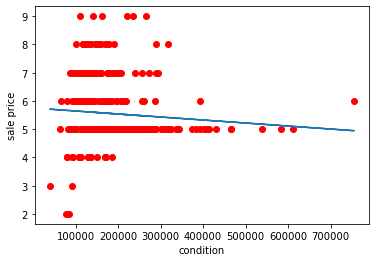

In [44]:
c = z.values

b_train, b_test, c_train, c_test = train_test_split(b,c)
b_test = b_test.reshape(-1,1)
b_train = b_train.reshape(-1,1)

lin_model = LinearRegression()
lin_model.fit(b_train,c_train)

lin_preds = lin_model.predict(b_test)

plt.scatter(b_test,c_test, color = 'red')
plt.plot(b_test, lin_preds)
plt.xlabel('condition')
plt.ylabel('sale price')
plt.show()



In [368]:
lin_model.coef_


array([-1.35663396e-06])

In [369]:

lin_model.intercept_

5.802429632949067

SUPPORT VECTOR MACHINE

In [374]:
vector_model = SVC()
vector_model.fit(train_x ,train_y)
vector_preds = vector_model.predict(val_x)

vector_model.score(val_x,val_y)

0.0136986301369863